In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset = pd.read_csv('/content/drive/MyDrive/CSVs/Heart_Disease.csv')

dataset.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,HeartDisease
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
dataset.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [4]:
print(dataset['HeartDisease'].value_counts())

HeartDisease
0    3594
1     644
Name: count, dtype: int64


In [5]:
bpmMedsMode = dataset['BPMeds'].mode()[0]         # categorical data
dataset['BPMeds'].fillna(bpmMedsMode, inplace=True)

educationMode = dataset['education'].mode()[0]   # categorical data
dataset['education'].fillna(educationMode, inplace=True)

cigsPerDayMean = dataset['cigsPerDay'].mean()    # numerical data
dataset['cigsPerDay'].fillna(cigsPerDayMean, inplace=True)

totCholMean = dataset['totChol'].mean()          # numerical data
dataset['totChol'].fillna(totCholMean, inplace=True)

bmiMean = dataset['BMI'].mean()                  # numerical data
dataset['BMI'].fillna(bmiMean, inplace=True)

heartRateMean = dataset['heartRate'].mean()      # numerical data
dataset['heartRate'].fillna(heartRateMean, inplace=True)

glucoseMean = dataset['glucose'].mean()          # numerical data
dataset['glucose'].fillna(glucoseMean, inplace=True)

def standard_scaling_columns(X, columnsToScale):
    XScaled = X.copy()

    for column in columnsToScale:
        if column in XScaled.columns:
            mean = XScaled[column].mean()
            standardDeviation = XScaled[column].std()

            if standardDeviation == 0:   # avoid division by zero
                standardDeviation = 1

            XScaled[column] = (XScaled[column] - mean) / standardDeviation

    return XScaled

In [6]:
X = dataset.drop(columns=['HeartDisease'])

columnsToScale = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']  # only numerical columns and not categorical columns

X = standard_scaling_columns(X, columnsToScale)

Y = dataset['HeartDisease']

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size = 0.3, random_state = 42, stratify = Y)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size = 0.5, random_state = 42, stratify = Y_temp)

#Part A

In [7]:
def sigmoid(z):
    clippedZ = np.clip(z, -500, 500)   # Clipping to prevent overflow in the exponential function
    return 1 / (1 + np.exp(-clippedZ))

In [8]:
def compute_cost(X, Y, parameters):
    m = len(Y)
    predictions = sigmoid(X.dot(parameters))
    predictions = np.clip(predictions, 1e-8, 1 - 1e-8)    # Clipping to prevent overflow in the logarithmic function

    logPredictions = np.log(predictions)
    logOneMinusPredictions = np.log(1 - predictions)

    firstTerm = Y.T.dot(logPredictions)
    secondTerm = (1 - Y).T.dot(logOneMinusPredictions)

    cost = (-1/m) * (firstTerm + secondTerm)

    return cost

In [9]:
def gradient_descent(X, Y, parameters, learning_rate, iterations, X_val, Y_val):
    m = len(Y)

    cost_history_train = np.zeros(iterations)
    accuracy_history_train = np.zeros(iterations)
    cost_history_val = np.zeros(iterations)
    accuracy_history_val = np.zeros(iterations)

    for i in range(iterations):
        predictions_train = sigmoid(X.dot(parameters))
        error = predictions_train - Y

        gradient = (learning_rate / m) * (X.T.dot(error))
        parameters -= gradient

        cost_train = compute_cost(X, Y, parameters)
        cost_history_train[i] = cost_train

        accuracy_train = np.mean((predictions_train >= 0.5) == Y)
        accuracy_history_train[i] = accuracy_train

        predictions_val = sigmoid(X_val.dot(parameters))
        cost_val = compute_cost(X_val, Y_val, parameters)
        accuracy_val = np.mean((predictions_val >= 0.5) == Y_val)

        cost_history_val[i] = cost_val
        accuracy_history_val[i] = accuracy_val

        if i % 1000 == 0:
            print("Iteration " + str(i) + ": Training Cost = " + str(cost_train) + ", Validation Cost = " + str(cost_val))

    return parameters, cost_history_train, accuracy_history_train, cost_history_val, accuracy_history_val

In [10]:
initial_parameters = np.zeros(X_train.shape[1])  # initialize parameters as zeros
learning_rate = 0.01
iterations = 5000

no_scaling_initial_parameters = initial_parameters.copy()
parameters, cost_history_train, accuracy_history_train, cost_history_val, accuracy_history_val = gradient_descent(X_train, Y_train, no_scaling_initial_parameters, learning_rate, iterations, X_val, Y_val)

Iteration 0: Training Cost = 0.6875419181226746, Validation Cost = 0.6874978470273305
Iteration 1000: Training Cost = 0.4192613070171523, Validation Cost = 0.4287639298840338
Iteration 2000: Training Cost = 0.41453038995456326, Validation Cost = 0.4268498928079236
Iteration 3000: Training Cost = 0.4120199711911742, Validation Cost = 0.42633409822822776
Iteration 4000: Training Cost = 0.4102925441886229, Validation Cost = 0.4261880819037209


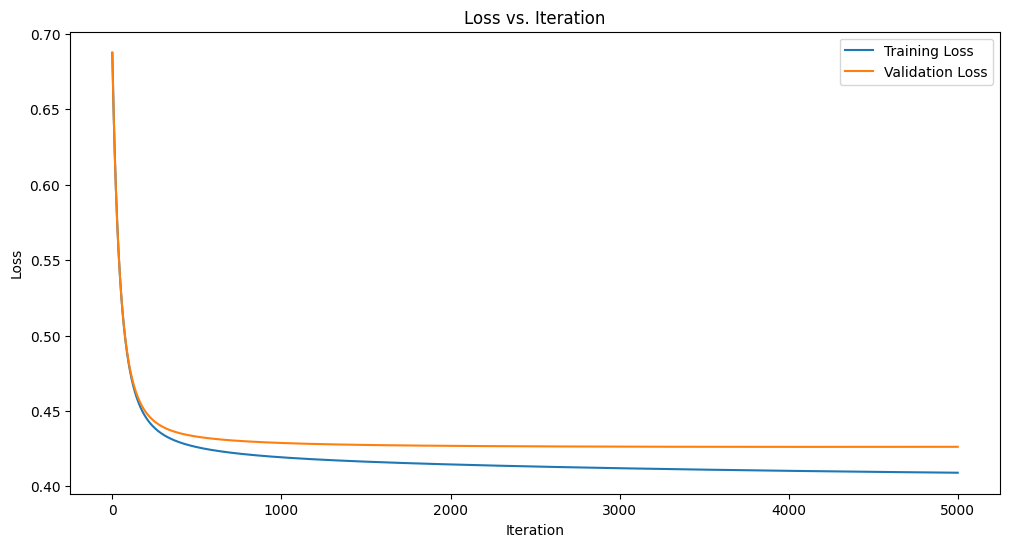

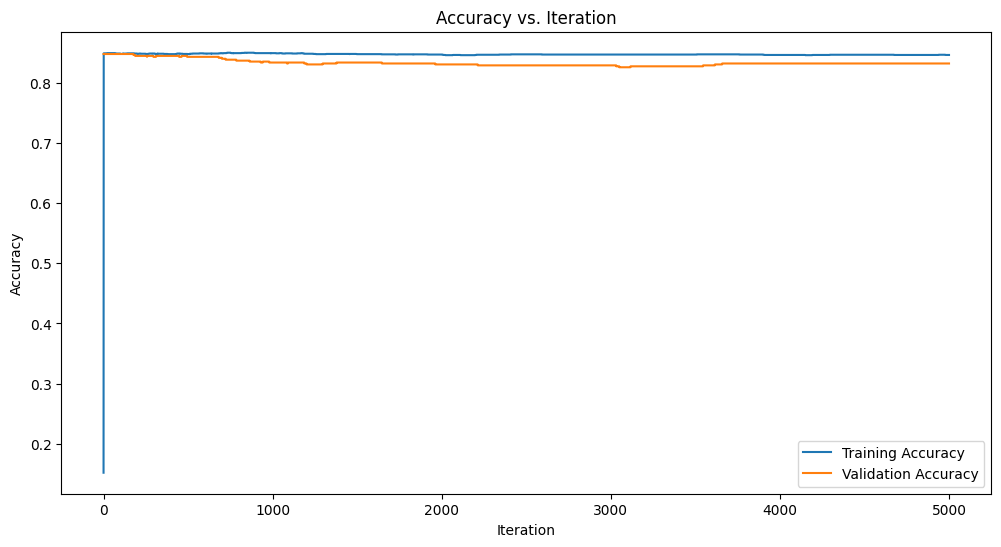



Final Validation Loss: 0.426229978732527
Final Validation Accuracy: 0.8317610062893082


In [11]:
import matplotlib.pyplot as plt

# Loss vs Iterations
plt.figure(figsize=(12, 6))
plt.plot(cost_history_train, label='Training Loss')
plt.plot(cost_history_val, label='Validation Loss')
plt.title('Loss vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Accuracy vs Iterations
plt.figure(figsize=(12, 6))
plt.plot(accuracy_history_train, label='Training Accuracy')
plt.plot(accuracy_history_val, label='Validation Accuracy')
plt.title('Accuracy vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print("\n")
print("Final Validation Loss: " + str(cost_history_val[-1]))
print("Final Validation Accuracy: " + str(accuracy_history_val[-1]))

#**Part B**

# Min Max Scaling

In [12]:
def min_max_scaling(X):
    X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)

    X_scaled = (X - X_min) / (X_max - X_min)

    return X_scaled

In [13]:
X_scaled = dataset.drop(columns=['HeartDisease'])

X_scaled = min_max_scaling(X_scaled)

X_scaled_train, X_scaled_temp, Y_scaled_train, Y_scaled_temp = train_test_split(X_scaled, Y, test_size = 0.3, random_state = 42, stratify = Y)
X_scaled_val, X_scaled_test, Y_scaled_val, Y_scaled_test = train_test_split(X_scaled_temp, Y_scaled_temp, test_size = 0.5, random_state = 42, stratify = Y_scaled_temp)

scaled_learning_rate = 0.01
scaled_iterations = 5000

scaled_initial_parameters = initial_parameters.copy()
scaled_parameters, cost_scaled_history_train, accuracy_scaled_history_train, cost_scaled_history_val, accuracy_scaled_history_val = gradient_descent(X_scaled_train, Y_scaled_train, scaled_initial_parameters, scaled_learning_rate, scaled_iterations, X_scaled_val, Y_scaled_val)

Iteration 0: Training Cost = 0.6918045477435615, Validation Cost = 0.6918277356549007
Iteration 1000: Training Cost = 0.4724290335680234, Validation Cost = 0.47843146172608464
Iteration 2000: Training Cost = 0.45942008607695234, Validation Cost = 0.46335005632233317
Iteration 3000: Training Cost = 0.4515082110089547, Validation Cost = 0.4531324885116613
Iteration 4000: Training Cost = 0.4458836298255587, Validation Cost = 0.44560490122382


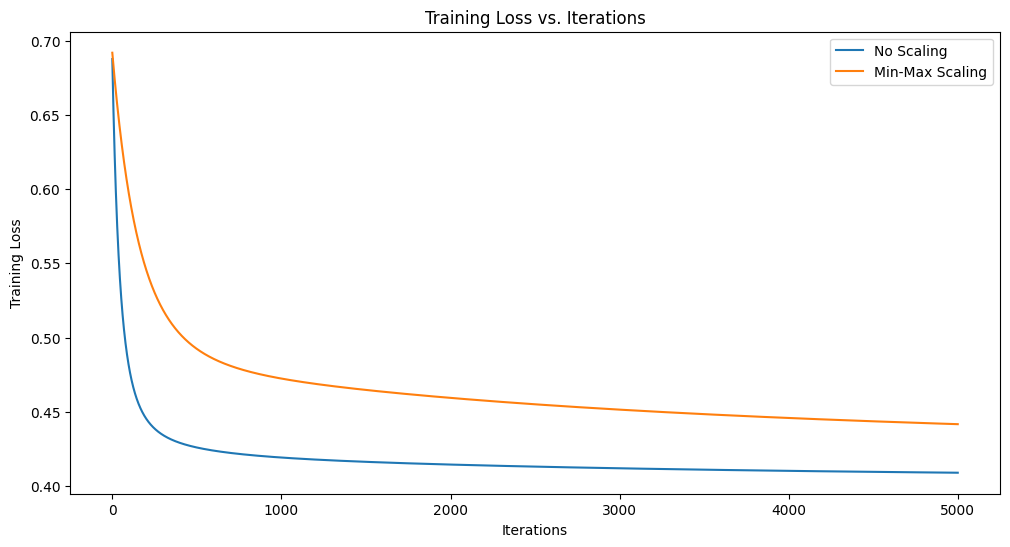

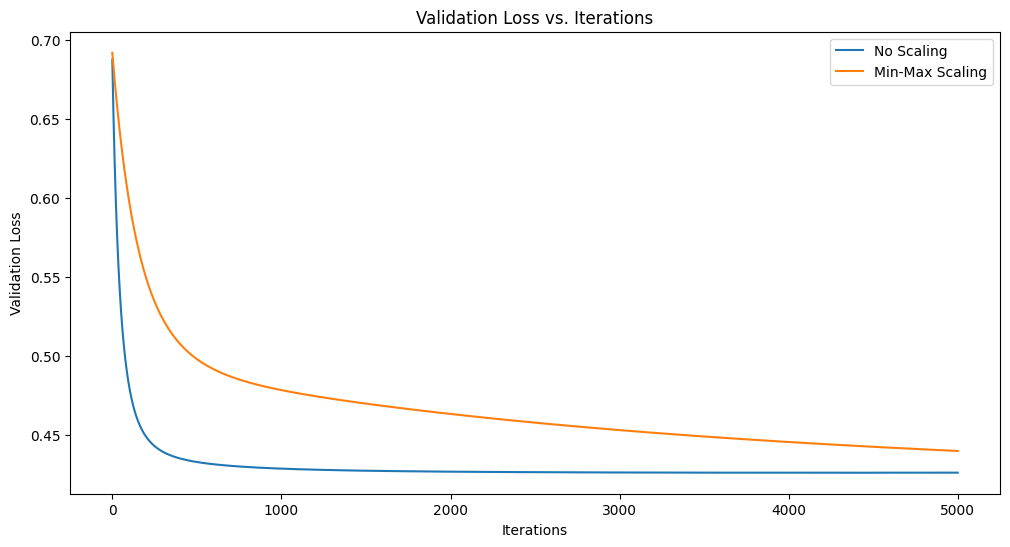

In [14]:
# Training Loss vs Iterations
plt.figure(figsize=(12, 6))
plt.plot(cost_history_train, label='No Scaling')
plt.plot(cost_scaled_history_train, label='Min-Max Scaling')
plt.title('Training Loss vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.legend()
plt.show()

# Validation vs Iterations
plt.figure(figsize=(12, 6))
plt.plot(cost_history_val, label='No Scaling')
plt.plot(cost_scaled_history_val, label='Min-Max Scaling')
plt.title('Validation Loss vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

#Part C

In [15]:
predictions_val = sigmoid(X_val.dot(parameters))
Y_pred_val = (predictions_val >= 0.5).astype(int)

Y_true_val = Y_val

In [16]:
def confusion_matrix(y_true, y_pred):
    trueNegative = np.sum((y_true == 0) & (y_pred == 0))
    falsePositive = np.sum((y_true == 0) & (y_pred == 1))
    falseNegative = np.sum((y_true == 1) & (y_pred == 0))
    truePositive = np.sum((y_true == 1) & (y_pred == 1))

    confMatrix = np.array([[trueNegative, falsePositive], [falseNegative, truePositive]])

    return confMatrix

confMatrix = confusion_matrix(Y_true_val, Y_pred_val)

trueNegative, falsePositive = confMatrix[0]
falseNegative, truePositive = confMatrix[1]

print("Confusion Matrix:")
print(confMatrix)

Confusion Matrix:
[[523  16]
 [ 91   6]]


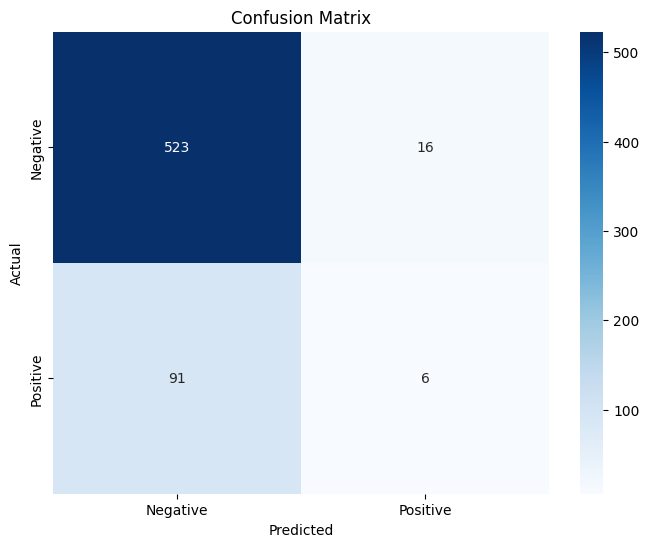

In [17]:
def plot_confusion_matrix(confMatrix, labels):
    plt.figure(figsize = (8, 6))
    sns.heatmap(confMatrix, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = labels, yticklabels = labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

labels = ['Negative', 'Positive']
plot_confusion_matrix(confMatrix, labels)

In [18]:
precision = truePositive / (truePositive + falsePositive)
recall = truePositive / (truePositive + falseNegative)
f1 = 2 * (precision * recall) / (precision + recall)

Y_pred_prob_val = sigmoid(X_val.dot(parameters))
roc_auc_score_val = roc_auc_score(Y_val, Y_pred_prob_val)

print("Precision: " + str(precision))
print("Recall: " + str(recall))
print("F1 Score: " + str(f1))
print("ROC-AUC Score:", roc_auc_score_val)

Precision: 0.2727272727272727
Recall: 0.061855670103092786
F1 Score: 0.10084033613445377
ROC-AUC Score: 0.6609987950194134


#Part D

In [19]:
def sigmoid(z):
    clippedZ = np.clip(z, -500, 500)   # Clipping to prevent overflow in the exponential function
    return 1 / (1 + np.exp(-clippedZ))

In [20]:
def compute_cost(X, Y, parameters):
    m = len(Y)
    predictions = sigmoid(X.dot(parameters))
    predictions = np.clip(predictions, 1e-8, 1 - 1e-8)    # Clipping to prevent overflow in the logarithmic function

    logPredictions = np.log(predictions)
    logOneMinusPredictions = np.log(1 - predictions)

    firstTerm = Y.T.dot(logPredictions)
    secondTerm = (1 - Y).T.dot(logOneMinusPredictions)

    cost = (-1/m) * (firstTerm + secondTerm)

    return cost

In [21]:
def stochastic_gradient_descent(X, Y, parameters, learning_rate, iterations, X_val, Y_val, X_test, Y_test):
    X = X.to_numpy()
    Y = Y.to_numpy()
    m = len(Y)

    cost_history_train = np.zeros(iterations)
    accuracy_history_train = np.zeros(iterations)
    cost_history_val = np.zeros(iterations)
    accuracy_history_val = np.zeros(iterations)
    cost_history_test = np.zeros(iterations)
    accuracy_history_test = np.zeros(iterations)

    for i in range(iterations):
        indices = np.arange(m)
        np.random.shuffle(indices)

        for j in range(m):
            index = indices[j]
            X_i = X[index:index + 1]
            Y_i = Y[index:index + 1]

            predictions = sigmoid(X_i.dot(parameters))
            error = predictions - Y_i

            gradient = X_i.T.dot(error)
            parameters -= learning_rate * gradient

        predictions_train = sigmoid(X.dot(parameters))
        cost_train = compute_cost(X, Y, parameters)
        accuracy_train = np.mean((predictions_train >= 0.5) == Y)
        cost_history_train[i] = cost_train
        accuracy_history_train[i] = accuracy_train

        X_val_np = X_val.to_numpy()
        Y_val_np = Y_val.to_numpy()
        predictions_val = sigmoid(X_val_np.dot(parameters))
        cost_val = compute_cost(X_val_np, Y_val_np, parameters)
        accuracy_val = np.mean((predictions_val >= 0.5) == Y_val_np)
        cost_history_val[i] = cost_val
        accuracy_history_val[i] = accuracy_val

        X_test_np = X_test.to_numpy()
        Y_test_np = Y_test.to_numpy()
        predictions_test = sigmoid(X_test_np.dot(parameters))
        cost_test = compute_cost(X_test_np, Y_test_np, parameters)
        accuracy_test = np.mean((predictions_test >= 0.5) == Y_test_np)
        cost_history_test[i] = cost_test
        accuracy_history_test[i] = accuracy_test

        if i % 100 == 0:
            print("Iteration " + str(i) + ": Training Cost = " + str(cost_train) + ", Validation Cost = " + str(cost_val) + ", Test Cost = " + str(cost_test))

    return (parameters, cost_history_train, accuracy_history_train, cost_history_val, accuracy_history_val, cost_history_test, accuracy_history_test)

In [22]:
def mini_batch_gradient_descent(X, Y, parameters, learning_rate, iterations, batch_size, X_val, Y_val, X_test, Y_test):
    X = X.to_numpy()
    Y = Y.to_numpy()
    m = len(Y)

    cost_history_train = np.zeros(iterations)
    accuracy_history_train = np.zeros(iterations)
    cost_history_val = np.zeros(iterations)
    accuracy_history_val = np.zeros(iterations)
    cost_history_test = np.zeros(iterations)
    accuracy_history_test = np.zeros(iterations)

    for i in range(iterations):
        for start in range(0, m, batch_size):
            end = min(start + batch_size, m)
            X_batch = X[start:end]
            Y_batch = Y[start:end]

            predictions = sigmoid(X_batch.dot(parameters))
            error = predictions - Y_batch
            gradient = (X_batch.T.dot(error)) / len(Y_batch)
            parameters -= learning_rate * gradient

        predictions_train = sigmoid(X.dot(parameters))
        cost_train = compute_cost(X, Y, parameters)
        accuracy_train = np.mean((predictions_train >= 0.5) == Y)
        cost_history_train[i] = cost_train
        accuracy_history_train[i] = accuracy_train

        X_val_np = X_val.to_numpy()
        Y_val_np = Y_val.to_numpy()
        predictions_val = sigmoid(X_val_np.dot(parameters))
        cost_val = compute_cost(X_val_np, Y_val_np, parameters)
        accuracy_val = np.mean((predictions_val >= 0.5) == Y_val_np)
        cost_history_val[i] = cost_val
        accuracy_history_val[i] = accuracy_val

        X_test_np = X_test.to_numpy()
        Y_test_np = Y_test.to_numpy()
        predictions_test = sigmoid(X_test_np.dot(parameters))
        cost_test = compute_cost(X_test_np, Y_test_np, parameters)
        accuracy_test = np.mean((predictions_test >= 0.5) == Y_test_np)
        cost_history_test[i] = cost_test
        accuracy_history_test[i] = accuracy_test

        if i % 100 == 0:
            print("Iteration " + str(i) + ": Training Cost = " + str(cost_train) + ", Validation Cost = " + str(cost_val) + ", Test Cost = " + str(cost_test))

    return (parameters, cost_history_train, accuracy_history_train, cost_history_val, accuracy_history_val, cost_history_test, accuracy_history_test)

In [23]:
# batch size 32
parameters_mbgd_32 = initial_parameters.copy()
params_mbgd_32, cost_history_train_mbgd_32, accuracy_history_train_mbgd_32, cost_history_val_mbgd_32, accuracy_history_val_mbgd_32, cost_history_test_mbgd_32, accuracy_history_test_mbgd_32 = mini_batch_gradient_descent(X_train, Y_train, parameters_mbgd_32, 0.0001, 2000, 32, X_val, Y_val, X_test, Y_test)

Iteration 0: Training Cost = 0.6879594227169831, Validation Cost = 0.6879185057209738, Test Cost = 0.6881007492867917
Iteration 100: Training Cost = 0.4843756294791945, Validation Cost = 0.4853898646614892, Test Cost = 0.4883067056007493
Iteration 200: Training Cost = 0.4481527483478719, Validation Cost = 0.45129754502535424, Test Cost = 0.4529978525788148
Iteration 300: Training Cost = 0.4359988425572553, Validation Cost = 0.4406737583103089, Test Cost = 0.4419959190304393
Iteration 400: Training Cost = 0.43026645081693576, Validation Cost = 0.4360590166037013, Test Cost = 0.4374750308984441
Iteration 500: Training Cost = 0.42692015806922556, Validation Cost = 0.43356958121683165, Test Cost = 0.4352841305487053
Iteration 600: Training Cost = 0.4246754912305723, Validation Cost = 0.4320113869250113, Test Cost = 0.434093574358019
Iteration 700: Training Cost = 0.4230268320225829, Validation Cost = 0.43093338221895683, Test Cost = 0.43338610057771493
Iteration 800: Training Cost = 0.4217

In [24]:
# batch size 64
parameters_mbgd_64 = initial_parameters.copy()
params_mbgd_64, cost_history_train_mbgd_64, accuracy_history_train_mbgd_64, cost_history_val_mbgd_64, accuracy_history_val_mbgd_64, cost_history_test_mbgd_64, accuracy_history_test_mbgd_64 = mini_batch_gradient_descent(X_train, Y_train, parameters_mbgd_64, 0.0001, 2000, 64, X_val, Y_val, X_test, Y_test)

Iteration 0: Training Cost = 0.6905030446518123, Validation Cost = 0.6904817032449987, Test Cost = 0.6905759622107724
Iteration 100: Training Cost = 0.5372593603975854, Validation Cost = 0.5371197485652077, Test Cost = 0.5405969008597336
Iteration 200: Training Cost = 0.48365281898739554, Validation Cost = 0.4846626206349219, Test Cost = 0.4876450991007191
Iteration 300: Training Cost = 0.4599433740259024, Validation Cost = 0.46210699821298007, Test Cost = 0.46436988232505455
Iteration 400: Training Cost = 0.4475424160500475, Validation Cost = 0.45069582105308353, Test Cost = 0.45246867807999314
Iteration 500: Training Cost = 0.4402389820536575, Validation Cost = 0.4442231012281999, Test Cost = 0.4457308164620807
Iteration 600: Training Cost = 0.43553501647628245, Validation Cost = 0.44021974283579507, Test Cost = 0.4416284071621609
Iteration 700: Training Cost = 0.4322836390905555, Validation Cost = 0.43756603202193295, Test Cost = 0.43898982142141907
Iteration 800: Training Cost = 0.

In [25]:
# Stochastic Gradient Descent
parameters_sgd = initial_parameters.copy()
params_sgd, cost_history_train_sgd, accuracy_history_train_sgd, cost_history_val_sgd, accuracy_history_val_sgd, cost_history_test_sgd, accuracy_history_test_sgd = stochastic_gradient_descent(X_train, Y_train, parameters_sgd, 0.0001, 2000, X_val, Y_val, X_test, Y_test)

Iteration 0: Training Cost = 0.5763246882899178, Validation Cost = 0.5759498221584172, Test Cost = 0.5790100898872914
Iteration 100: Training Cost = 0.4120320656337528, Validation Cost = 0.42634233456024656, Test Cost = 0.4298577018522354
Iteration 200: Training Cost = 0.4081442407521091, Validation Cost = 0.4263729377277507, Test Cost = 0.42791003684351975
Iteration 300: Training Cost = 0.40649812138424174, Validation Cost = 0.42701055923366893, Test Cost = 0.427491659863776
Iteration 400: Training Cost = 0.40571364903362, Validation Cost = 0.4276517610793346, Test Cost = 0.4276451878628692
Iteration 500: Training Cost = 0.4053013346310984, Validation Cost = 0.4281783231705036, Test Cost = 0.427963414768941
Iteration 600: Training Cost = 0.40506354256832455, Validation Cost = 0.4285972911210267, Test Cost = 0.428296884724096
Iteration 700: Training Cost = 0.4049132087646688, Validation Cost = 0.4289237800088675, Test Cost = 0.4285962477722423
Iteration 800: Training Cost = 0.404809500

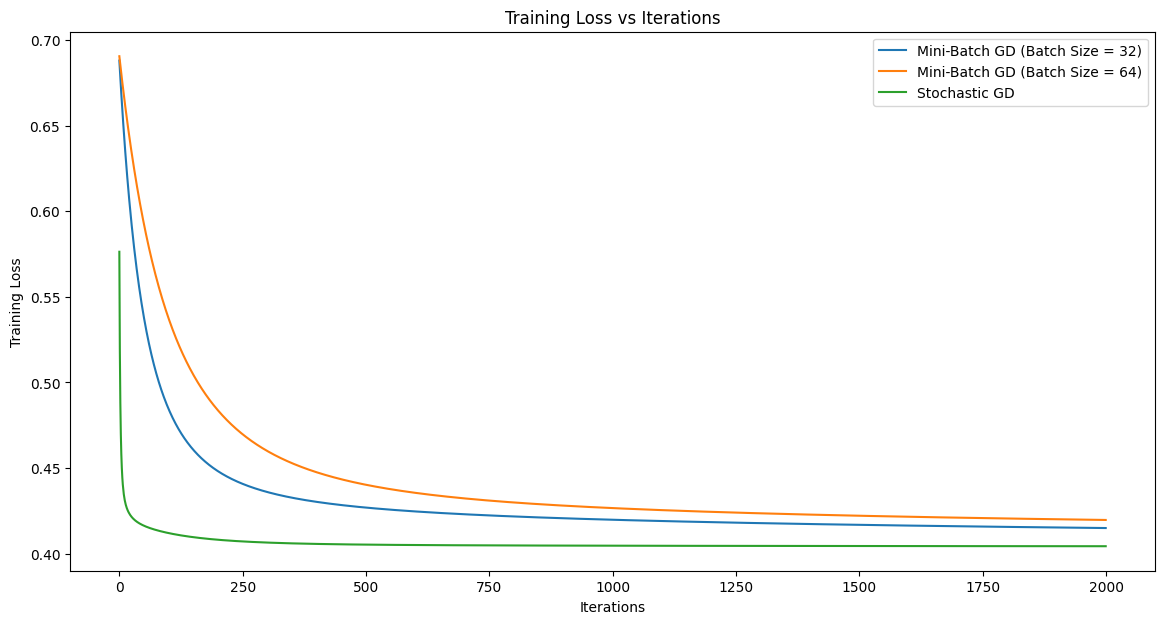

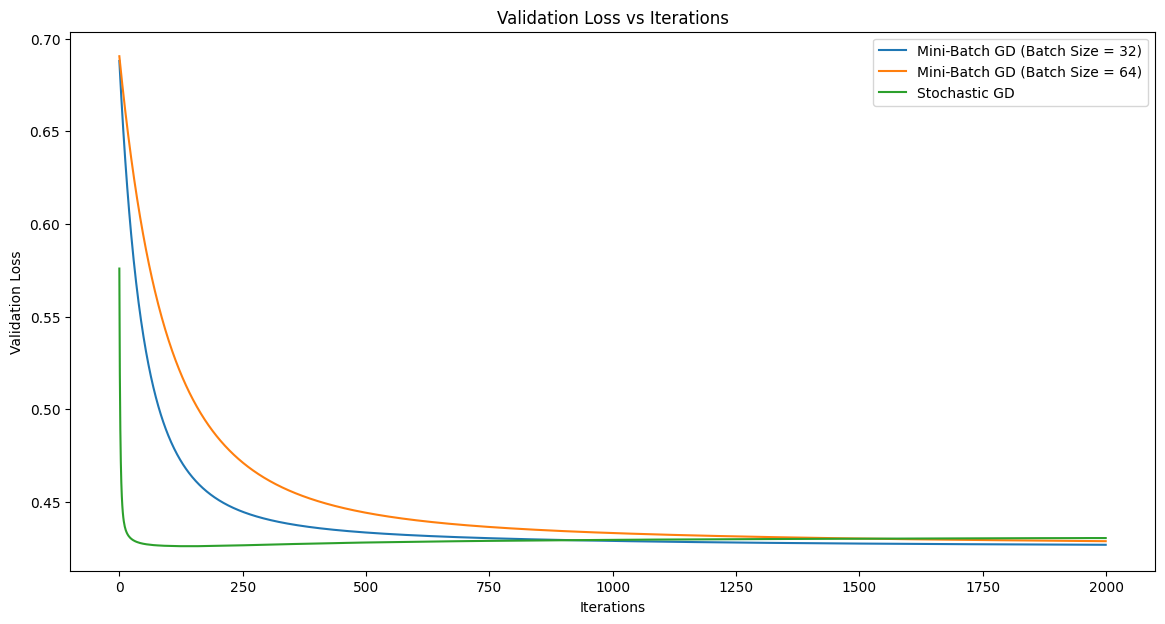

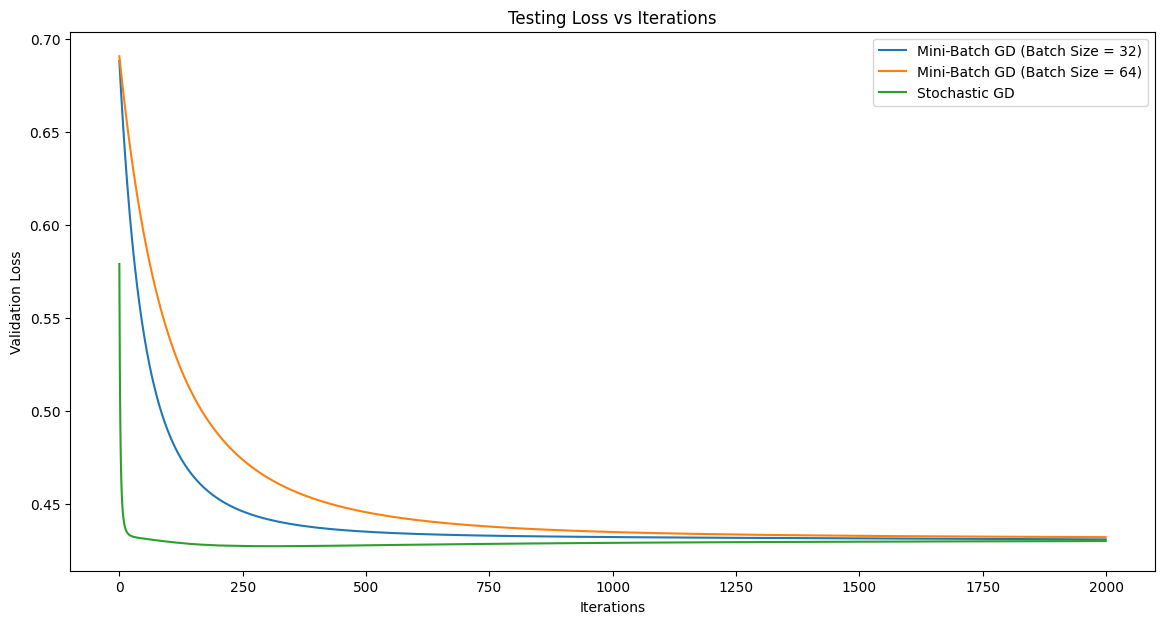

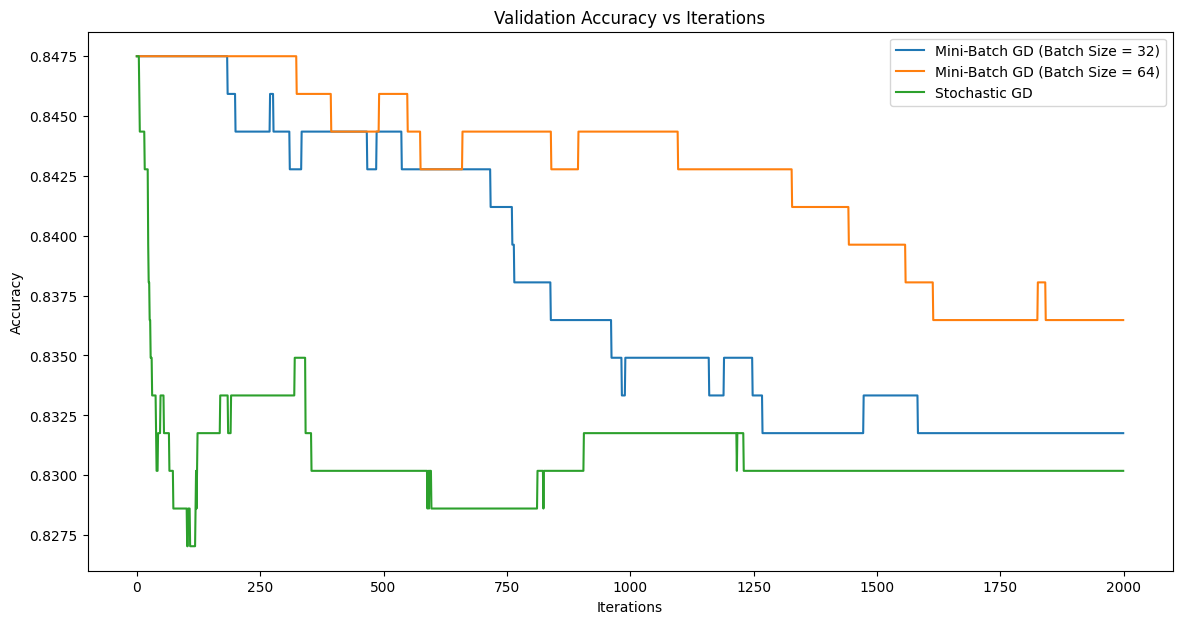

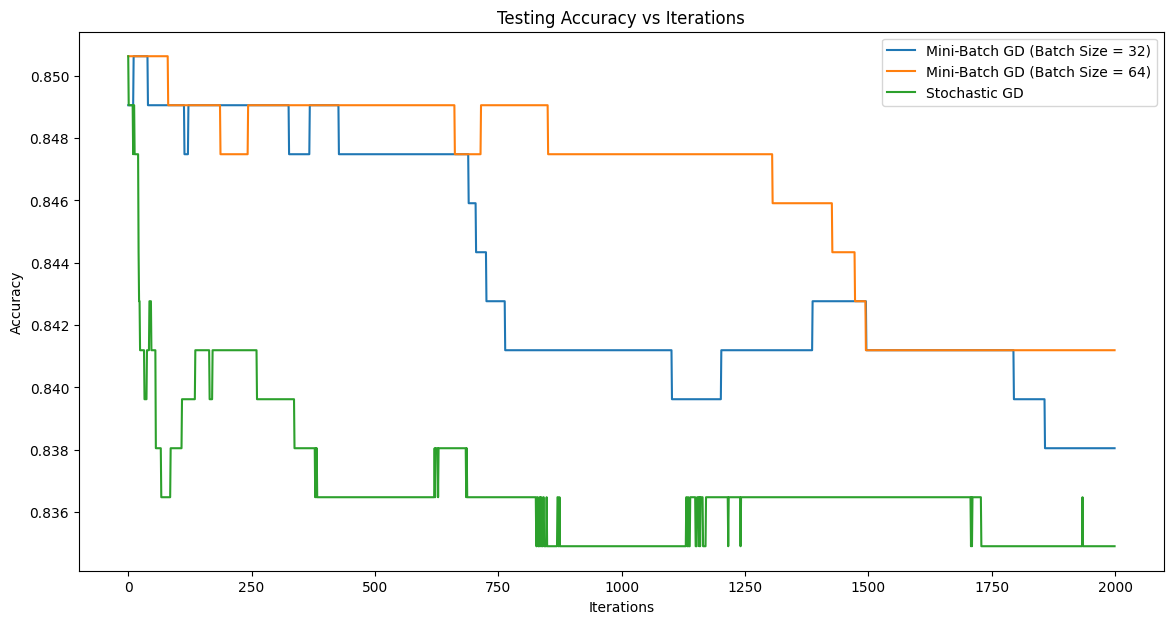

In [26]:
# training loss vs iterations
plt.figure(figsize=(14, 7))
plt.plot(cost_history_train_mbgd_32, label='Mini-Batch GD (Batch Size = 32)')
plt.plot(cost_history_train_mbgd_64, label='Mini-Batch GD (Batch Size = 64)')
plt.plot(cost_history_train_sgd, label='Stochastic GD')
plt.title('Training Loss vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.legend()
plt.show()

print("\n")
# validation loss vs iterations
plt.figure(figsize=(14, 7))
plt.plot(cost_history_val_mbgd_32, label='Mini-Batch GD (Batch Size = 32)')
plt.plot(cost_history_val_mbgd_64, label='Mini-Batch GD (Batch Size = 64)')
plt.plot(cost_history_val_sgd, label='Stochastic GD')
plt.title('Validation Loss vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

print("\n")
# testing loss vs iterations
plt.figure(figsize=(14, 7))
plt.plot(cost_history_test_mbgd_32, label='Mini-Batch GD (Batch Size = 32)')
plt.plot(cost_history_test_mbgd_64, label='Mini-Batch GD (Batch Size = 64)')
plt.plot(cost_history_test_sgd, label='Stochastic GD')
plt.title('Testing Loss vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

print("\n")
# validation accuracy vs iterations
plt.figure(figsize=(14, 7))
plt.plot(accuracy_history_val_mbgd_32, label='Mini-Batch GD (Batch Size = 32)')
plt.plot(accuracy_history_val_mbgd_64, label='Mini-Batch GD (Batch Size = 64)')
plt.plot(accuracy_history_val_sgd, label='Stochastic GD')
plt.title('Validation Accuracy vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print("\n")
# testing accuracy vs  vs iterations
plt.figure(figsize=(14, 7))
plt.plot(accuracy_history_test_mbgd_32, label='Mini-Batch GD (Batch Size = 32)')
plt.plot(accuracy_history_test_mbgd_64, label='Mini-Batch GD (Batch Size = 64)')
plt.plot(accuracy_history_test_sgd, label='Stochastic GD')
plt.title('Testing Accuracy vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Part E

Iteration 0: Training Cost = 0.6875293089974212, Validation Cost = 0.6875686542479794
Iteration 1000: Training Cost = 0.4190654476736777, Validation Cost = 0.4233429695687297
Iteration 2000: Training Cost = 0.415036037452047, Validation Cost = 0.4187163125109803
Iteration 3000: Training Cost = 0.41303378492728127, Validation Cost = 0.41533189211744037
Iteration 4000: Training Cost = 0.41169607187001334, Validation Cost = 0.4126803783947285
Fold 1 completed.

Iteration 0: Training Cost = 0.687568522436634, Validation Cost = 0.6875107914835499
Iteration 1000: Training Cost = 0.41914042475312274, Validation Cost = 0.4201711437582364
Iteration 2000: Training Cost = 0.4142243195345983, Validation Cost = 0.41698998739862675
Iteration 3000: Training Cost = 0.4116395062659534, Validation Cost = 0.41513338092570445
Iteration 4000: Training Cost = 0.4098561129718437, Validation Cost = 0.4137326670725361
Fold 2 completed.

Iteration 0: Training Cost = 0.6876322374741107, Validation Cost = 0.68741

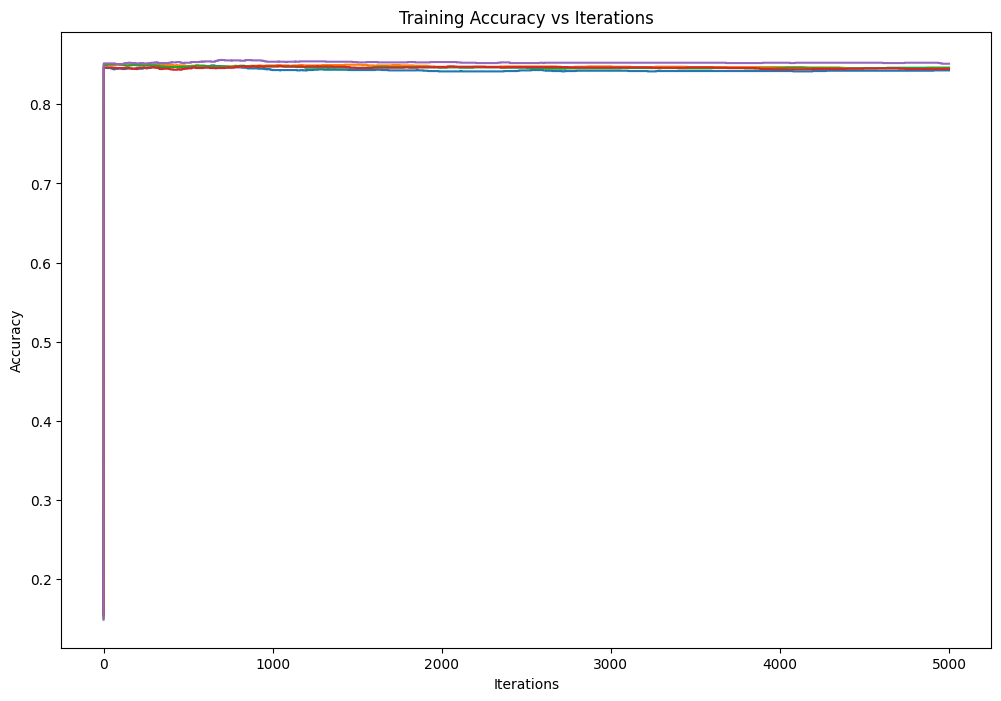

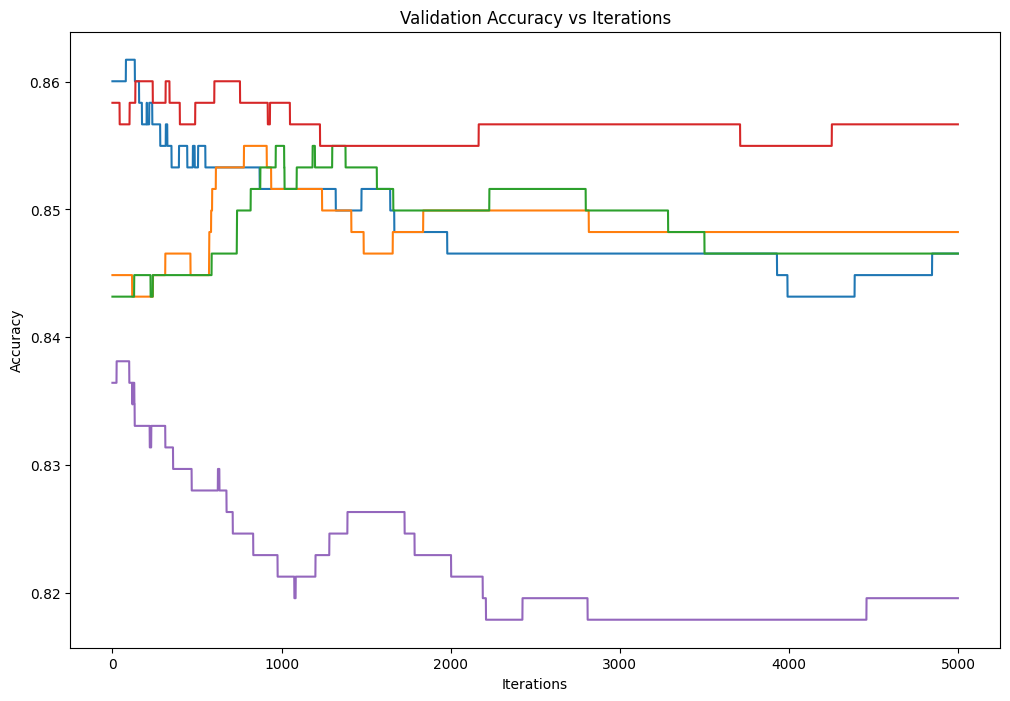

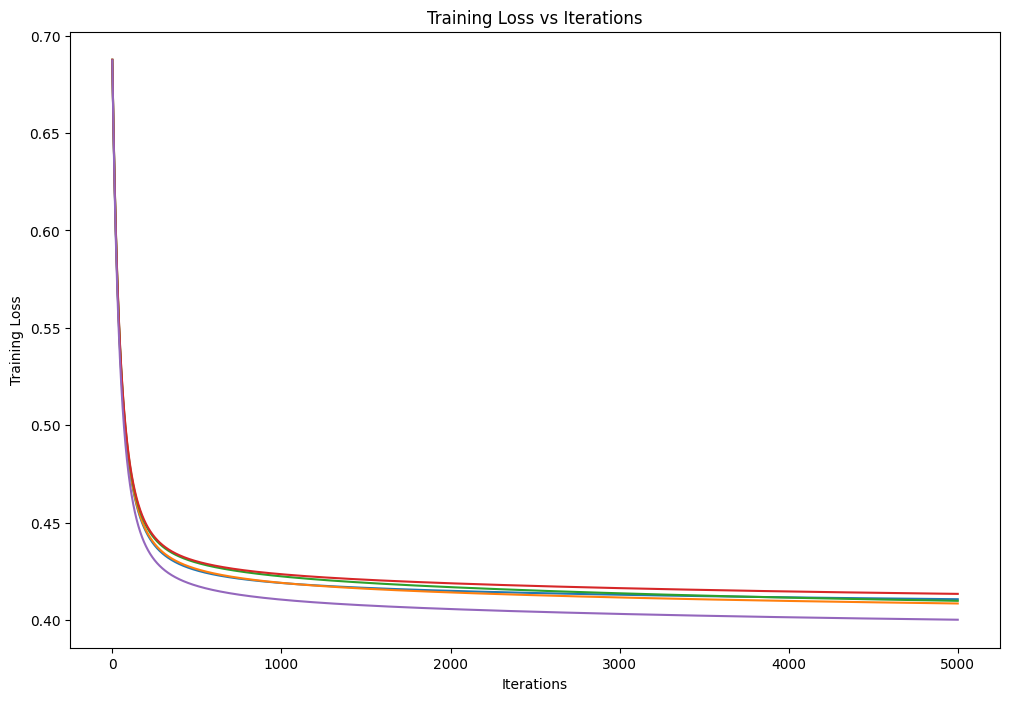

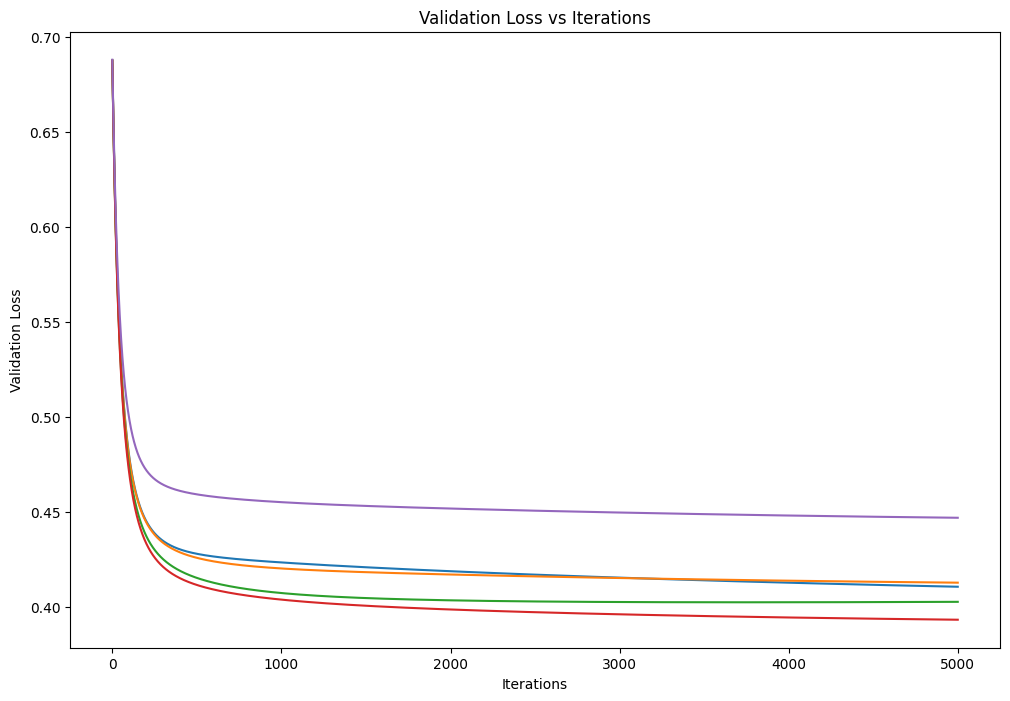



Accuracy:
 Mean = 0.8435075885328838, Standard Deviation = 0.012547099654460908

Precision:
 Mean = 0.45235978835978835, Standard Deviation = 0.09912696139274474

Recall:
 Mean = 0.10668420818390327, Standard Deviation = 0.016312625549698742

F1 Score:
 Mean = 0.17183823131388834, Standard Deviation = 0.026273403990808106



In [27]:
def k_fold_cross_validation(X, Y, initial_parameters, learning_rate, iterations, k):
    X = np.array(X)
    Y = np.array(Y)

    indices = np.arange(X.shape[0])
    np.random.seed(42)      # reproducible random numbers
    np.random.shuffle(indices)
    X, Y = X[indices], Y[indices]

    fold_size = X.shape[0] // k
    folds_X = []
    folds_Y = []

    start_index = 0

    for i in range(k):
        end_index = start_index + fold_size

        fold_X = X[start_index:end_index]
        fold_Y = Y[start_index:end_index]

        folds_X.append(fold_X)
        folds_Y.append(fold_Y)

        start_index = end_index

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    accuracy_histories_train = []
    accuracy_histories_val = []
    cost_histories_train = []
    cost_histories_val = []

    fold = 1
    for i in range(k):
        X_val = folds_X[i]
        Y_val = folds_Y[i]

        X_train = []
        Y_train = []
        for j in range(k):
            if j != i:
                X_train.append(folds_X[j])
                Y_train.append(folds_Y[j])
        X_train = np.concatenate(X_train, axis=0)
        Y_train = np.concatenate(Y_train, axis=0)

        params = initial_parameters.copy()

        params, cost_history_train, accuracy_history_train, cost_history_val, accuracy_history_val = gradient_descent(X_train, Y_train, params, learning_rate, iterations, X_val, Y_val)

        accuracy_histories_train.append(accuracy_history_train)
        accuracy_histories_val.append(accuracy_history_val)
        cost_histories_train.append(cost_history_train)
        cost_histories_val.append(cost_history_val)

        predictions = sigmoid(np.dot(X_val, params)) >= 0.5

        accuracy_scores.append(accuracy_score(Y_val, predictions))
        precision_scores.append(precision_score(Y_val, predictions))
        recall_scores.append(recall_score(Y_val, predictions))
        f1_scores.append(f1_score(Y_val, predictions))

        print("Fold " + str(fold) + " completed.\n")
        fold += 1

    results = {}

    accuracy_mean = np.mean(accuracy_scores)
    accuracy_std = np.std(accuracy_scores)
    results['Accuracy'] = (accuracy_mean, accuracy_std)

    precision_mean = np.mean(precision_scores)
    precision_std = np.std(precision_scores)
    results['Precision'] = (precision_mean, precision_std)

    recall_mean = np.mean(recall_scores)
    recall_std = np.std(recall_scores)
    results['Recall'] = (recall_mean, recall_std)

    f1_mean = np.mean(f1_scores)
    f1_std = np.std(f1_scores)
    results['F1 Score'] = (f1_mean, f1_std)


    # training accuracy vs iterations
    plt.figure(figsize=(12, 8))
    for fold in range(k):
        plt.plot(accuracy_histories_train[fold], label = 'Fold ' + str(fold + 1) + ' Training Accuracy')
    plt.title('Training Accuracy vs Iterations')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.show()
    print('\n')

    # validation accuracy vs iterations
    plt.figure(figsize=(12, 8))
    for fold in range(k):
        plt.plot(accuracy_histories_val[fold], label = 'Fold ' + str(fold + 1) + ' Validation Accuracy')
    plt.title('Validation Accuracy vs Iterations')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.show()
    print('\n')

    # training loss vs iterations
    plt.figure(figsize=(12, 8))
    for fold in range(k):
        plt.plot(cost_histories_train[fold], label = 'Fold ' + str(fold + 1) + ' Training Loss')
    plt.title('Training Loss vs Iterations')
    plt.xlabel('Iterations')
    plt.ylabel('Training Loss')
    plt.show()
    print('\n')

    # validation loss vs iterations
    plt.figure(figsize=(12, 8))
    for fold in range(k):
        plt.plot(cost_histories_val[fold], label = 'Fold ' + str(fold + 1) + ' Validation Loss')
    plt.title('Validation Loss vs Iterations')
    plt.xlabel('Iterations')
    plt.ylabel('Validation Loss')
    plt.show()
    print('\n')

    return results

initial_parameters = np.zeros(X_train.shape[1])
results = k_fold_cross_validation(X_train, Y_train, initial_parameters, 0.01, 5000, 5)

for metric, (mean, std) in results.items():
    print(metric + ":\n Mean = " + str(mean) + ", Standard Deviation = " + str(std) + "\n")

#Part F

In [28]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, params, regularization, lambda_):
    m = len(y)
    h = sigmoid(X.dot(params))
    cost = -1/m * (y.T.dot(np.log(h)) + (1 - y).T.dot(np.log(1 - h)))

    if regularization == "L2":
        cost += (lambda_ / (2 * m)) * np.sum(np.square(params))
    elif regularization == "L1":
        cost += (lambda_ / (2 * m)) * np.sum(np.abs(params))

    return cost

def gradient_descent_without(X_train, y_train, X_val, y_val, params, learning_rate, iterations, lambda_, regularization):
    m = len(y_train)
    cost_history_train = []
    accuracy_history_train = []
    cost_history_val = []
    accuracy_history_val = []

    for i in range(iterations):
        h_train = sigmoid(X_train.dot(params))

        if regularization == "L2":
            gradients = (1/m) * X_train.T.dot(h_train - y_train) + (lambda_ / m) * params
        elif regularization == "L1":
            gradients = (1/m) * X_train.T.dot(h_train - y_train) + (lambda_ / m) * np.sign(params)
        else:
            gradients = (1/m) * X_train.T.dot(h_train - y_train)  # No regularization

        params -= learning_rate * gradients

        cost_train = compute_cost(X_train, y_train, params, regularization, lambda_)
        cost_val = compute_cost(X_val, y_val, params, regularization, lambda_)

        cost_history_train.append(cost_train)
        cost_history_val.append(cost_val)

        predictions_train = h_train >= 0.5
        accuracy_train = np.mean(predictions_train == y_train)
        accuracy_history_train.append(accuracy_train)

        h_val = sigmoid(X_val.dot(params))
        predictions_val = h_val >= 0.5
        accuracy_val = np.mean(predictions_val == y_val)
        accuracy_history_val.append(accuracy_val)

        if i % 100 == 0:
            print("Iteration " + str(i) + ", Training Cost: " + str(cost_train) + ", Validation Cost: " + str(cost_val))

    return params, cost_history_train, accuracy_history_train, cost_history_val, accuracy_history_val

def gradient_descent_with(X_train, y_train, X_val, y_val, params, learning_rate, iterations, patience, lambda_, regularization):
    m = len(y_train)
    cost_history_train = []
    accuracy_history_train = []
    cost_history_val = []
    accuracy_history_val = []
    best_val_loss = float('inf')
    no_improvement = 0
    best_params = params.copy()

    for i in range(iterations):
        h_train = sigmoid(X_train.dot(params))

        if regularization == "L2":
            gradients = (1/m) * X_train.T.dot(h_train - y_train) + (lambda_ / m) * params
        elif regularization == "L1":
            gradients = (1/m) * X_train.T.dot(h_train - y_train) + (lambda_ / m) * np.sign(params)
        else:
            gradients = (1/m) * X_train.T.dot(h_train - y_train)

        params -= learning_rate * gradients

        cost_train = compute_cost(X_train, y_train, params, regularization, lambda_)
        cost_val = compute_cost(X_val, y_val, params, regularization, lambda_)

        cost_history_train.append(cost_train)
        cost_history_val.append(cost_val)

        predictions_train = h_train >= 0.5
        accuracy_train = np.mean(predictions_train == y_train)
        accuracy_history_train.append(accuracy_train)

        h_val = sigmoid(X_val.dot(params))
        predictions_val = h_val >= 0.5
        accuracy_val = np.mean(predictions_val == y_val)
        accuracy_history_val.append(accuracy_val)

        if cost_val < best_val_loss:
            best_val_loss = cost_val
            best_params = params.copy()
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print("Early stopping at iteration " + str(i) + "\n")
            break

        if i % 100 == 0:
            print("Iteration " + str(i) + ", Training Cost: " + str(cost_train) + ", Validation Cost: " + str(cost_val))


    return best_params, cost_history_train, accuracy_history_train, cost_history_val, accuracy_history_val

In [29]:
l1_initial_parameters = np.zeros(X_train.shape[1])
l2_initial_parameters = np.zeros(X_train.shape[1])
no_initial_parameters = np.zeros(X_train.shape[1])

learning_rate = 0.1
iterations = 2000
lambda_=0.01
patience=10

# L1 Regularization with early stopping
best_params_l1, cost_history_train_l1, accuracy_history_train_l1, cost_history_val_l1, accuracy_history_val_l1 = gradient_descent_with(X_train, Y_train, X_val, Y_val, l1_initial_parameters, learning_rate, iterations, patience, lambda_, "L1")

# L2 Regularization with early stopping
best_params_l2, cost_history_train_l2, accuracy_history_train_l2, cost_history_val_l2, accuracy_history_val_l2 = gradient_descent_with(X_train, Y_train, X_val, Y_val, l2_initial_parameters, learning_rate, iterations, patience, lambda_, "L2")

# No Regularization with early stopping
best_params_no, cost_history_train_no, accuracy_history_train_no, cost_history_val_no, accuracy_history_val_no = gradient_descent_with(X_train, Y_train, X_val, Y_val, no_initial_parameters,learning_rate, iterations, patience,lambda_, "None")

l1_initial_parameters = np.zeros(X_train.shape[1])
l2_initial_parameters = np.zeros(X_train.shape[1])
no_initial_parameters = np.zeros(X_train.shape[1])

# L1 Regularization without early stopping
best_params_l1_wo, cost_history_train_l1_wo, accuracy_history_train_l1_wo, cost_history_val_l1_wo, accuracy_history_val_l1_wo = gradient_descent_without(X_train, Y_train,  X_val, Y_val, l1_initial_parameters, learning_rate, iterations, lambda_, "L1")

print('\n')
# L2 Regularization without early stopping
best_params_l2_wo, cost_history_train_l2_wo, accuracy_history_train_l2_wo, cost_history_val_l2_wo, accuracy_history_val_l2_wo = gradient_descent_without(X_train, Y_train, X_val, Y_val, l2_initial_parameters, learning_rate, iterations, lambda_, "L2")

print('\n')
# No Regularization without early stopping
best_params_no_wo, cost_history_train_no_wo, accuracy_history_train_no_wo, cost_history_val_no_wo, accuracy_history_val_no_wo = gradient_descent_without(X_train, Y_train, X_val, Y_val, no_initial_parameters, learning_rate, iterations, lambda_, "None")

Iteration 0, Training Cost: 0.6404310864296741, Validation Cost: 0.6400881793733778
Iteration 100, Training Cost: 0.41916887638509953, Validation Cost: 0.4287355451035297
Iteration 200, Training Cost: 0.4145053869272736, Validation Cost: 0.42686559474252556
Iteration 300, Training Cost: 0.4120073727265919, Validation Cost: 0.426357568841761
Iteration 400, Training Cost: 0.41028549476022474, Validation Cost: 0.4262150238253783
Early stopping at iteration 428

Iteration 0, Training Cost: 0.6404308521538322, Validation Cost: 0.6400870868228324
Iteration 100, Training Cost: 0.4191647018610815, Validation Cost: 0.4287229247540232
Iteration 200, Training Cost: 0.41450063266732534, Validation Cost: 0.4268515739125931
Iteration 300, Training Cost: 0.4120023935204613, Validation Cost: 0.4263431649531848
Iteration 400, Training Cost: 0.4102804627324916, Validation Cost: 0.4262006691516573
Early stopping at iteration 428

Iteration 0, Training Cost: 0.6404308426419837, Validation Cost: 0.64008704

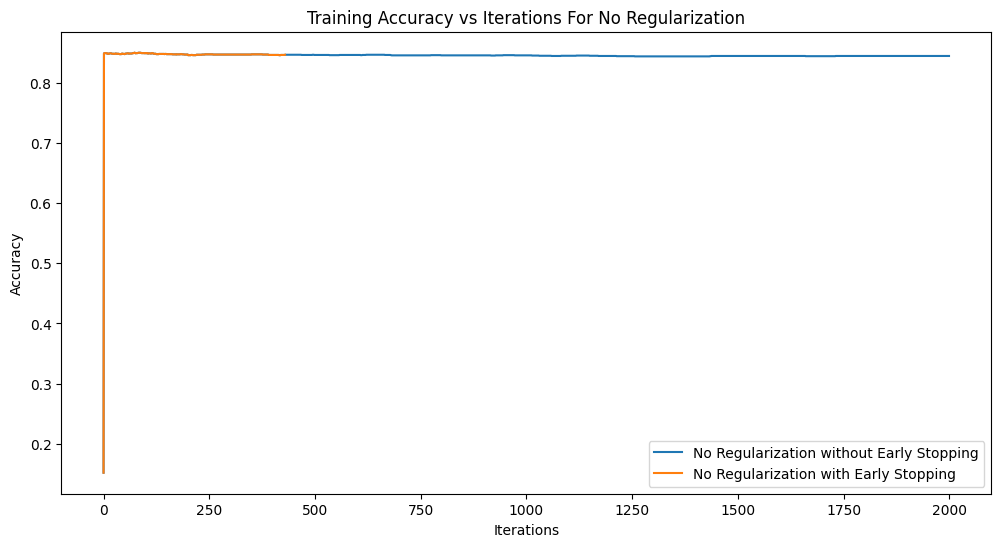

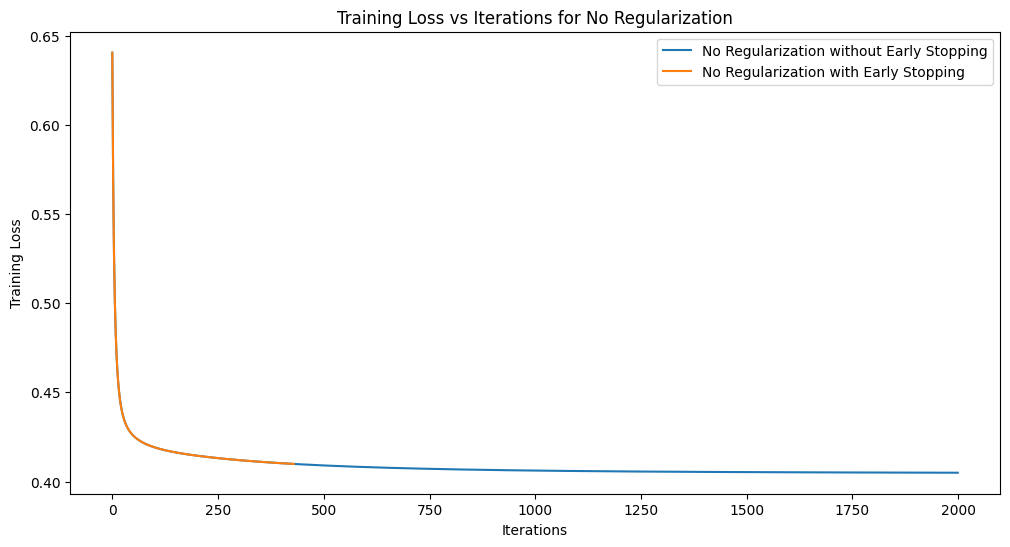

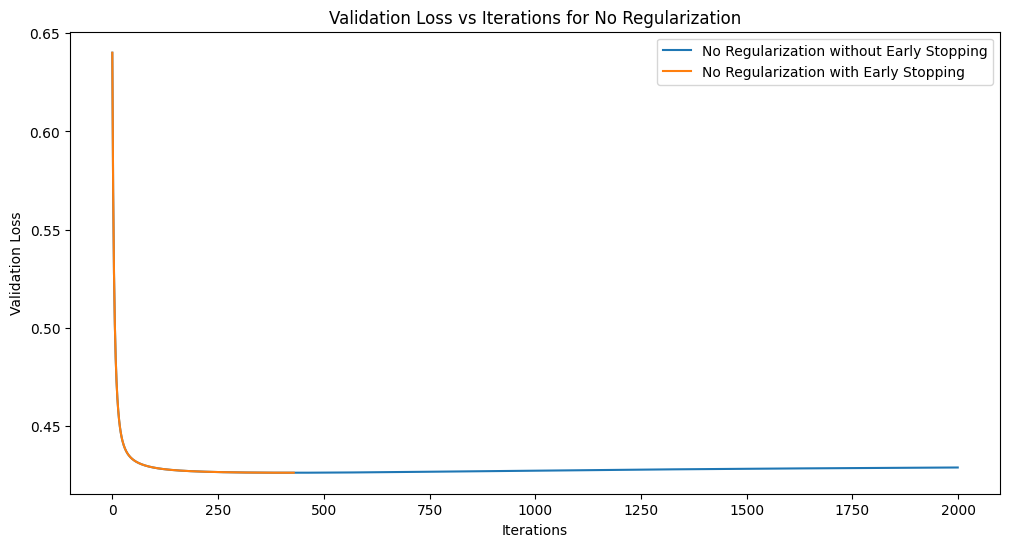

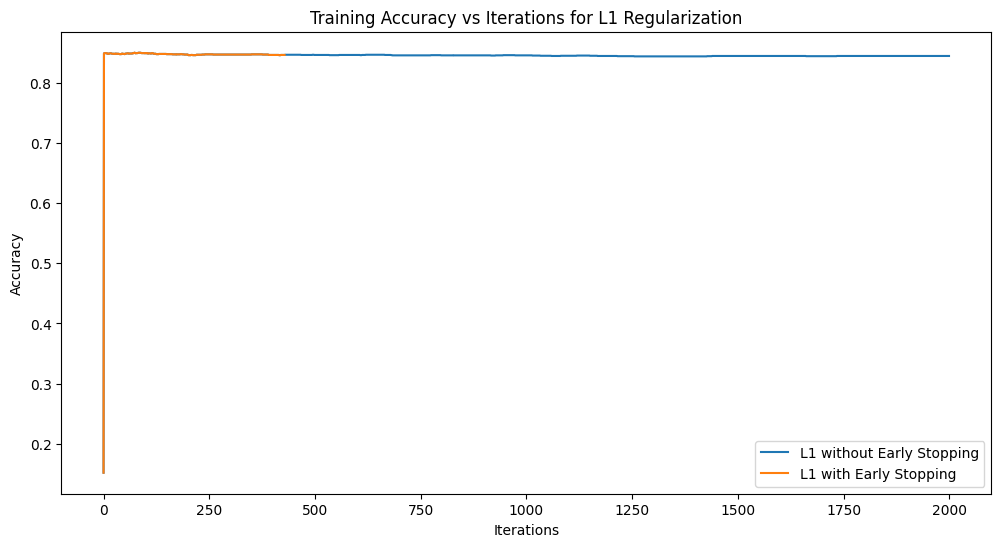

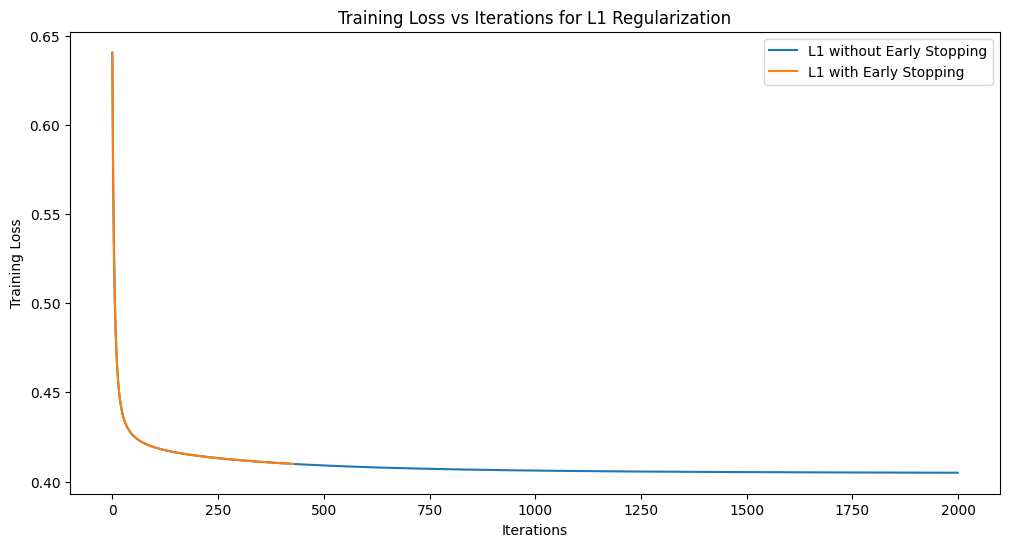

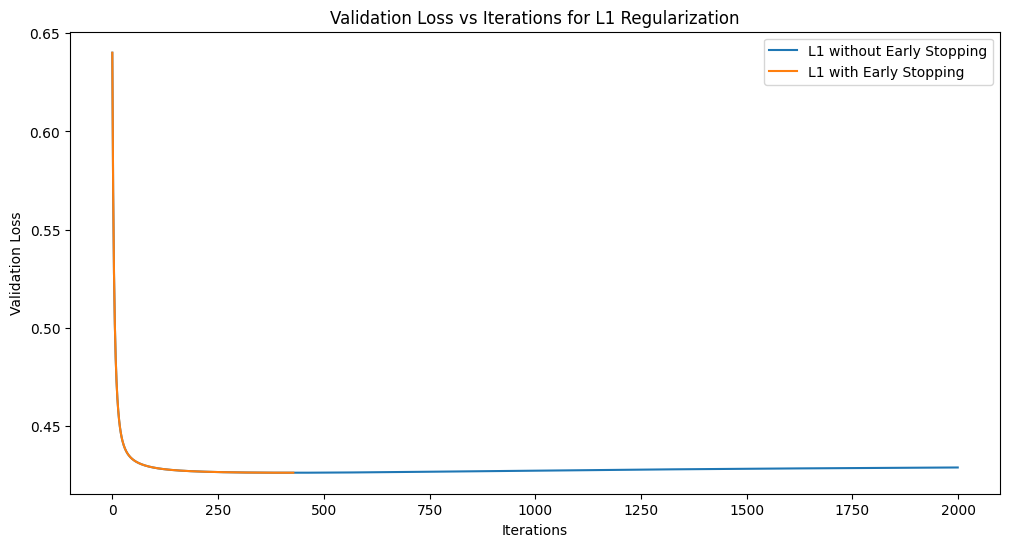

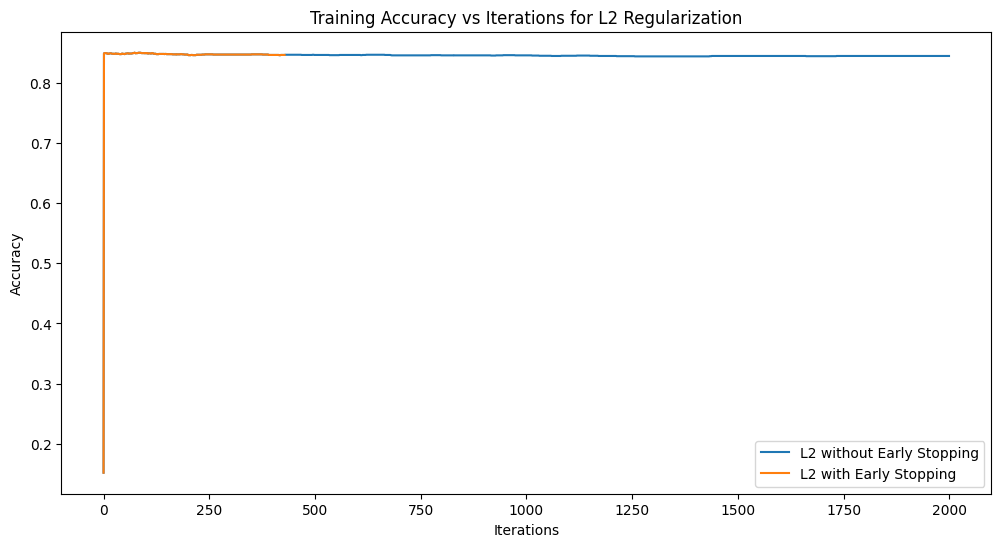

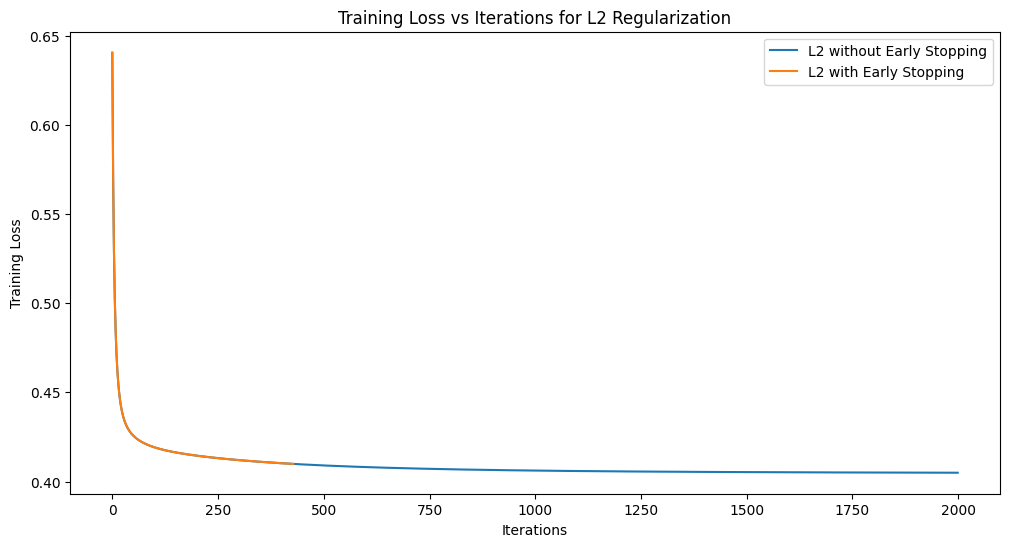

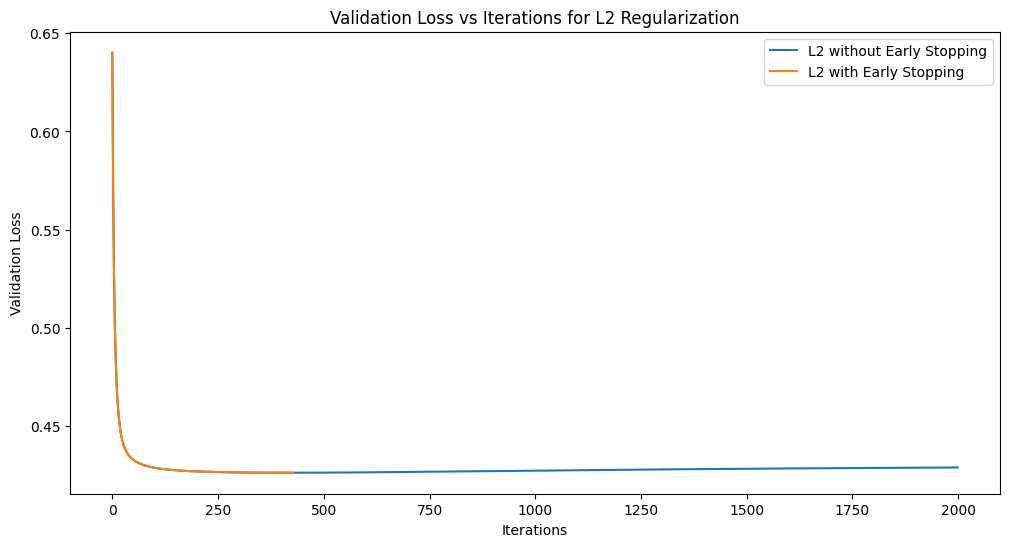

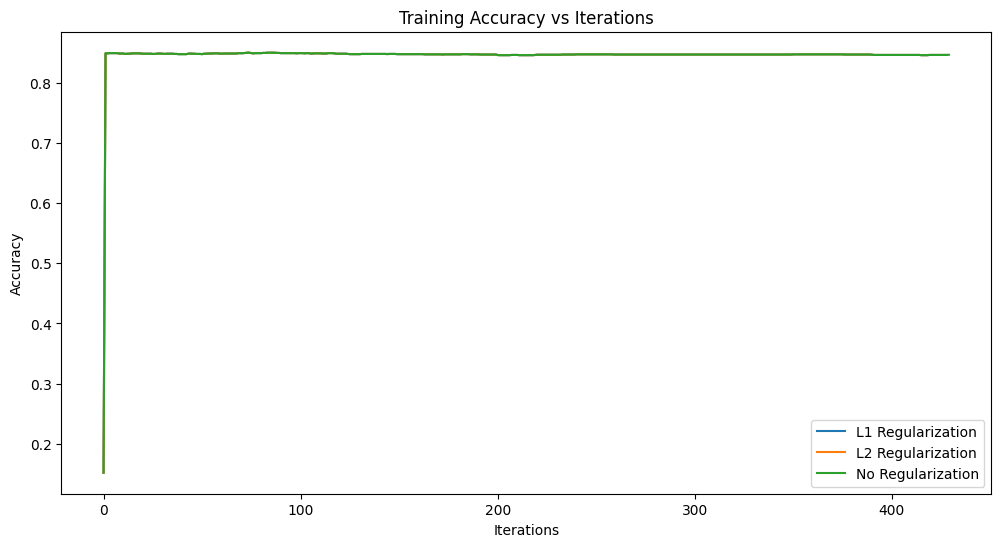

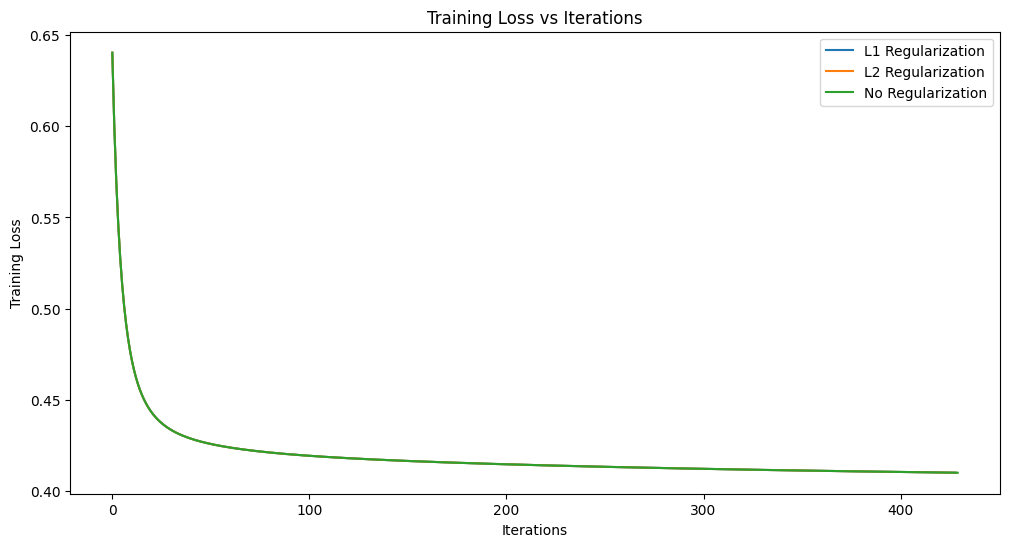

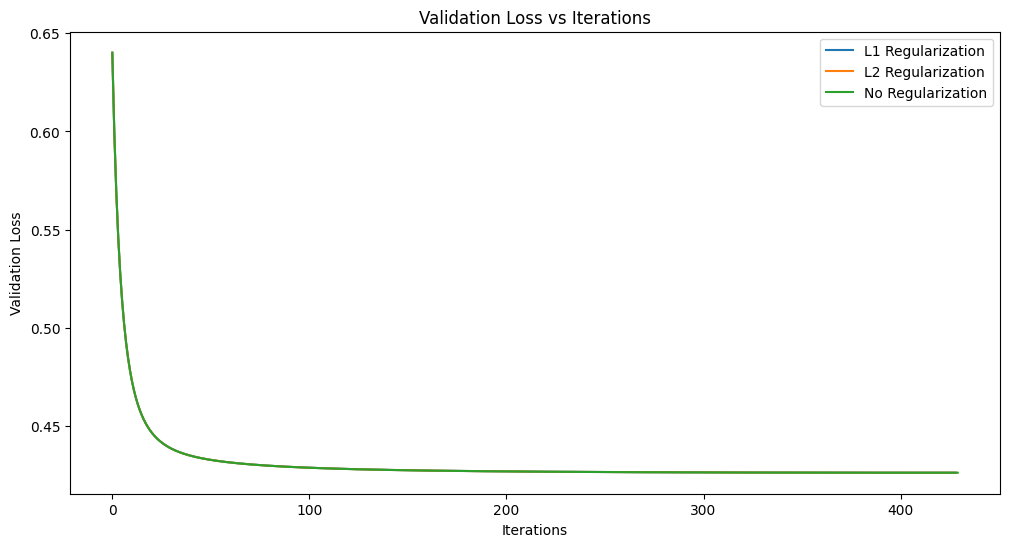

In [30]:
# Training Accuracy vs Iterations For No Regularization
plt.figure(figsize=(12, 6))
plt.plot(accuracy_history_train_no_wo, label='No Regularization without Early Stopping')
plt.plot(accuracy_history_train_no, label='No Regularization with Early Stopping')
plt.title('Training Accuracy vs Iterations For No Regularization')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print('\n')
# Training Loss vs Iterations for No Regularization
plt.figure(figsize=(12, 6))
plt.plot(cost_history_train_no_wo, label='No Regularization without Early Stopping')
plt.plot(cost_history_train_no, label='No Regularization with Early Stopping')
plt.title('Training Loss vs Iterations for No Regularization')
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.legend()
plt.show()

print('\n')
# Validation Loss vs Iterations for No Regularization
plt.figure(figsize=(12, 6))
plt.plot(cost_history_val_no_wo, label='No Regularization without Early Stopping')
plt.plot(cost_history_val_no, label='No Regularization with Early Stopping')
plt.title('Validation Loss vs Iterations for No Regularization')
plt.xlabel('Iterations')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

print('\n')
# Training Accuracy vs Iterations for L1 Regularization
plt.figure(figsize=(12, 6))
plt.plot(accuracy_history_train_l1_wo, label='L1 without Early Stopping')
plt.plot(accuracy_history_train_l1, label='L1 with Early Stopping')
plt.title('Training Accuracy vs Iterations for L1 Regularization')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print('\n')
# Training Loss vs Iterations for L1 Regularization
plt.figure(figsize=(12, 6))
plt.plot(cost_history_train_l1_wo, label='L1 without Early Stopping')
plt.plot(cost_history_train_l1, label='L1 with Early Stopping')
plt.title('Training Loss vs Iterations for L1 Regularization')
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.legend()
plt.show()

print('\n')
# Validation Loss vs Iterations for L1 Regularization
plt.figure(figsize=(12, 6))
plt.plot(cost_history_val_l1_wo, label='L1 without Early Stopping')
plt.plot(cost_history_val_l1, label='L1 with Early Stopping')
plt.title('Validation Loss vs Iterations for L1 Regularization')
plt.xlabel('Iterations')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

print('\n')
# Training Accuracy vs Iterations for L2 Regularization
plt.figure(figsize=(12, 6))
plt.plot(accuracy_history_train_l2_wo, label='L2 without Early Stopping')
plt.plot(accuracy_history_train_l2, label='L2 with Early Stopping')
plt.title('Training Accuracy vs Iterations for L2 Regularization')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print('\n')
# Training Loss vs Iterations for L2 Regularization
plt.figure(figsize=(12, 6))
plt.plot(cost_history_train_l2_wo, label='L2 without Early Stopping')
plt.plot(cost_history_train_l2, label='L2 with Early Stopping')
plt.title('Training Loss vs Iterations for L2 Regularization')
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.legend()
plt.show()

print('\n')
# Validation Loss vs Iterations for L2 Regularization
plt.figure(figsize=(12, 6))
plt.plot(cost_history_val_l2_wo, label='L2 without Early Stopping')
plt.plot(cost_history_val_l2, label='L2 with Early Stopping')
plt.title('Validation Loss vs Iterations for L2 Regularization')
plt.xlabel('Iterations')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

print('\n')
# Training Accuracy vs Iterations for all 3
plt.figure(figsize=(12, 6))
plt.plot(accuracy_history_train_l1, label='L1 Regularization')
plt.plot(accuracy_history_train_l2, label='L2 Regularization')
plt.plot(accuracy_history_train_no, label='No Regularization')
plt.title('Training Accuracy vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print('\n')
# Training Loss vs Iterations for all 3
plt.figure(figsize=(12, 6))
plt.plot(cost_history_train_l1, label='L1 Regularization')
plt.plot(cost_history_train_l2, label='L2 Regularization')
plt.plot(cost_history_train_no, label='No Regularization')
plt.title('Training Loss vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.legend()
plt.show()

print('\n')
# Validation Loss vs Iterations for all 3
plt.figure(figsize=(12, 6))
plt.plot(cost_history_val_l1, label='L1 Regularization')
plt.plot(cost_history_val_l2, label='L2 Regularization')
plt.plot(cost_history_val_no, label='No Regularization')
plt.title('Validation Loss vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()